In [13]:
import tensorflow as tf

IMG_SIZE = (96,96)      # STM32 friendly
BATCH_SIZE = 32
DATA_DIR = "Rice_Image_Dataset"
SEED = 123

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE
)

num_classes = len(train_ds.class_names)


Found 21604 files belonging to 5 classes.
Using 17284 files for training.
Found 21619 files belonging to 5 classes.
Using 4323 files for validation.


In [14]:
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])

def preprocess(x,y):
    x = tf.cast(x, tf.float32) / 255.0
    x = data_aug(x)
    return x,y

train_ds = train_ds.map(preprocess).shuffle(500).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x,y:(tf.cast(x,tf.float32)/255.0,y)).prefetch(tf.data.AUTOTUNE)


In [15]:
def se_block(x):
    c = x.shape[-1]
    y = tf.keras.layers.GlobalAveragePooling2D()(x)
    y = tf.keras.layers.Dense(c//8, activation="relu")(y)
    y = tf.keras.layers.Dense(c, activation="sigmoid")(y)
    y = tf.keras.layers.Reshape((1,1,c))(y)
    return tf.keras.layers.Multiply()([x,y])

def mbconv(x, filters, stride):
    in_ch = x.shape[-1]

    y = tf.keras.layers.DepthwiseConv2D(3, strides=stride, padding="same", use_bias=False)(x)
    y = tf.keras.layers.BatchNormalization()(y)
    y = tf.keras.layers.ReLU()(y)

    y = se_block(y)

    y = tf.keras.layers.Conv2D(filters, 1, use_bias=False)(y)
    y = tf.keras.layers.BatchNormalization()(y)

    if stride == 1 and in_ch == filters:
        y = tf.keras.layers.Add()([x,y])

    return y

def build_tiny_efficientnet(input_shape=(96,96,1), classes=5):
    inputs = tf.keras.layers.Input(shape=input_shape)

    # Stem
    x = tf.keras.layers.Conv2D(16, 3, strides=2, padding="same", use_bias=False)(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # EfficientNet blocks
    x = mbconv(x, 16, 1)
    x = mbconv(x, 24, 2)
    x = mbconv(x, 24, 1)
    x = mbconv(x, 40, 2)
    x = mbconv(x, 40, 1)

    # Head
    x = tf.keras.layers.Conv2D(64, 1, use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs)


In [16]:
model = build_tiny_efficientnet(classes=num_classes)
model.summary()
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(train_ds, validation_data=val_ds, epochs=30)


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 48, 48,    │        144 │ input_layer_7[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │         64 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_21 (ReLU)     │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_15 │ (None, 48, 48,    │        144 │ re_lu_21[0][0]    │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │         64 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_22 (ReLU)     │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ re_lu_22[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 2)         │         34 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 16)        │         48 │ dense_33[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_15          │ (None, 1, 1, 16)  │          0 │ dense_34[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_15         │ (None, 48, 48,    │          0 │ re_lu_22[0][0],   │
│ (Multiply)          │ 16)               │            │ reshape_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 48, 48,    │        256 │ multiply_15[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │         64 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 48, 48,    │          0 │ re_lu_21[0][0],   │
│                     │ 16)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_16 │ (None, 24, 24,    │        144 │ add_9[0][0]       │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │         64 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 10,212 (39.89 KB)

 Trainable params: 9,524 (37.20 KB)

 Non-trainable params: 688 (2.69 KB)

Epoch 1/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 108s 105ms/step - accuracy: 0.8004 - loss: 0.5446 - val_accuracy: 0.2794 - val_loss: 6.3749
Epoch 2/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 82s 106ms/step - accuracy: 0.9487 - loss: 0.1539 - val_accuracy: 0.4594 - val_loss: 3.9560
Epoch 3/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 84s 111ms/step - accuracy: 0.9593 - loss: 0.1149 - val_accuracy: 0.6542 - val_loss: 0.9579
Epoch 4/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 88s 117ms/step - accuracy: 0.9637 - loss: 0.1046 - val_accuracy: 0.7879 - val_loss: 0.5199
Epoch 5/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 85s 109ms/step - accuracy: 0.9657 - loss: 0.0970 - val_accuracy: 0.7092 - val_loss: 0.9799
Epoch 6/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.9701 - loss: 0.0863 - val_accuracy: 0.7525 - val_loss: 1.1754
Epoch 7/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 115s 164ms/step - accuracy: 0.9721 - loss: 0.0816 - val_accuracy: 0.7222 - val_loss: 2.1674
Epoch 8/30
541/541 ━━━━━━━━━━━━━━━━━━━━ 97s 122ms/step - accuracy: 0.9724 - loss

In [18]:
# Assuming your model variable is named 'model'
model.save('efficientnet_model.h5')

print("Model saved successfully as efficientnet_model.h5")

Model saved successfully as efficientnet_model.h5


Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Representative dataset shape: (5000, 96, 96, 1)
INFO:tensorflow:Assets written to: C:\Users\ng822\AppData\Local\Temp\tmpo80owzqd\assets


INFO:tensorflow:Assets written to: C:\Users\ng822\AppData\Local\Temp\tmpo80owzqd\assets


Saved artifact at 'C:\Users\ng822\AppData\Local\Temp\tmpo80owzqd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name='input_layer_7')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2557633253392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2557633262224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2557633254736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2557633257232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2557633252816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2557633264912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2557633250512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2557633251664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2557633253200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2557633250320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  255763

c:\Users\ng822\anaconda3\envs\421\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 TFLite model saved: rice_efficientnet_stm32.tflite
Input dtype: <class 'numpy.uint8'>
Input shape: [ 1 96 96  1]


c:\Users\ng822\anaconda3\envs\421\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Total test images: 26010
TFLITE INT8 ACCURACY = 90.43%

Confusion Matrix
[[4561    0  289   19  702]
 [   0 5123   23   25    0]
 [   0    1 5101    1   21]
 [  61  596  737 3684    5]
 [   7    0    1    0 5053]]


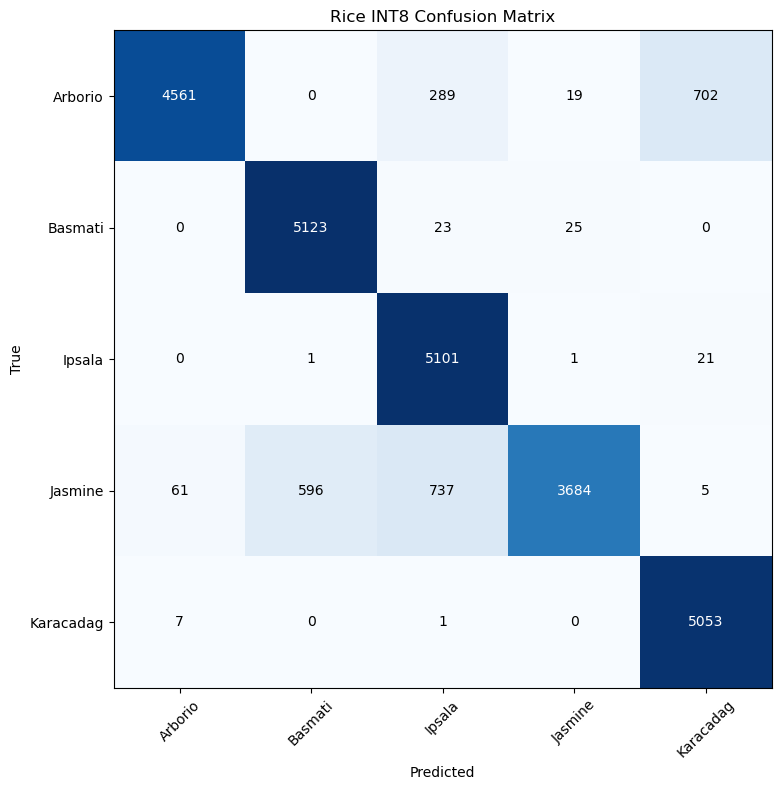

In [47]:
import tensorflow as tf
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

# ==============================
# CONFIG
# ==============================
MODEL_PATH = "efficientnet_model.h5"
DATA_DIR = "Rice_Image_Dataset"
IMG_SIZE = 96
TFLITE_PATH = "rice_efficientnet_stm32.tflite"
BATCH_SIZE = 32
SEED = 123

# ==============================
# 1. Load trained model
# ==============================
model = tf.keras.models.load_model(MODEL_PATH)
class_names = sorted(os.listdir(DATA_DIR))
num_classes = len(class_names)
print("Classes:", class_names)

# ==============================
# 2. Prepare representative dataset
# ==============================
rep_images = []

for cls_idx, cls in enumerate(class_names):
    cls_path = os.path.join(DATA_DIR, cls)
    imgs = os.listdir(cls_path)[:1000]  # take 20 images per class
    for f in imgs:
        path = os.path.join(cls_path, f)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, -1)   # (H,W,1)
        img = np.expand_dims(img, 0)    # (1,H,W,1)
        rep_images.append(img)

rep_images = np.vstack(rep_images)  # shape: [num_samples, H, W, 1]
print("Representative dataset shape:", rep_images.shape)

def representative_data_gen():
    for i in range(rep_images.shape[0]):
        yield [rep_images[i:i+1]]  # batch of 1, 4D tensor

# ==============================
# 3. INT8 TFLite conversion (weights + activations quantized)
# ==============================
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8   # input quantized
converter.inference_output_type = tf.uint8  # output quantized

tflite_model = converter.convert()

# ==============================
# 4. Save TFLite model
# ==============================
with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)
print("INT8 TFLite model saved:", TFLITE_PATH)

# ==============================
# 5. Load TFLite model and test
# ==============================
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input dtype:", input_details[0]['dtype'])
print("Input shape:", input_details[0]['shape'])

# ==============================
# 6. Load full test dataset
# ==============================
X = []
y = []

for idx, cls in enumerate(class_names):
    cls_path = os.path.join(DATA_DIR, cls)
    for f in os.listdir(cls_path):
        path = os.path.join(cls_path, f)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, -1)
        X.append(img)
        y.append(idx)

X = np.array(X, dtype=np.float32)
y = np.array(y)
print("Total test images:", len(X))

# ==============================
# 7. Quantize test images to uint8
# ==============================
input_scale, input_zero_point = input_details[0]['quantization']
X_uint8 = (X / input_scale + input_zero_point).astype(np.uint8)

# ==============================
# 8. Run TFLite inference
# ==============================
y_pred = []

for i in range(len(X_uint8)):
    img = np.expand_dims(X_uint8[i], 0)
    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()
    out = interpreter.get_tensor(output_details[0]['index'])
    pred = np.argmax(out)
    y_pred.append(pred)

y_pred = np.array(y_pred)

# ==============================
# 9. Accuracy
# ==============================
acc = np.mean(y_pred == y) * 100
print(f"TFLITE INT8 ACCURACY = {acc:.2f}%")

# ==============================
# 10. Confusion Matrix
# ==============================
cm = np.zeros((num_classes, num_classes), dtype=np.int32)
for t, p in zip(y, y_pred):
    cm[t, p] += 1

print("\nConfusion Matrix")
print(cm)

# ==============================
# 11. Plot confusion matrix
# ==============================
plt.figure(figsize=(8,8))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i,j], ha="center", va="center",
                 color="white" if cm[i,j] > cm.max()/2 else "black")

plt.title("Rice INT8 Confusion Matrix")
plt.tight_layout()
plt.show()


In [37]:
import os

def convert_tflite2cc(tflite_path, cc_path, model_name="efficientnet_model"):
    """Converts a TFLite file to a C++ file containing a byte array."""
    with open(tflite_path, 'rb') as f:
        tflite_content = f.read()
    
    hex_line = [f'0x{byte:02x}' for byte in tflite_content]
    
    with open(cc_path, 'w') as f:
        f.write(f'#include "{model_name}.h"\n\n')
        f.write(f'const unsigned char g_{model_name}_data[] = {{\n')
        # Write 12 hex values per line for readability
        for i in range(0, len(hex_line), 12):
            f.write('  ' + ', '.join(hex_line[i:i+12]) + ',\n')
        f.write(f'}};\n\n')
        f.write(f'const int g_{model_name}_data_len = {len(tflite_content)};\n')

# Generate the .cc file
convert_tflite2cc(TFLITE_PATH, "efficientnet_model.cc")

In [49]:
def generate_h_file(h_path, model_name="efficientnet_model"):
    with open(h_path, 'w') as f:
        f.write(f'#ifndef {model_name.upper()}_DATA_H_\n')
        f.write(f'#define {model_name.upper()}_DATA_H_\n\n')
        f.write(f'extern const unsigned char g_{model_name}_data[];\n')
        f.write(f'extern const int g_{model_name}_data_len;\n\n')
        f.write(f'#endif // {model_name.upper()}_DATA_H_\n')

# Generate the .h file
generate_h_file("efficientnet_model.h")

In [50]:
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

print("=== Tensors ===")
for t in interpreter.get_tensor_details():
    print(
        f"name={t['name']}, "
        f"shape={t['shape']}, "
        f"dtype={t['dtype']}"
    )

print("\n=== Ops ===")
for op in interpreter._get_ops_details():
    print(op["op_name"])


=== Tensors ===
name=serving_default_input_layer_7:0, shape=[ 1 96 96  1], dtype=<class 'numpy.uint8'>
name=arith.constant, shape=[2], dtype=<class 'numpy.int32'>
name=arith.constant1, shape=[1], dtype=<class 'numpy.int32'>
name=arith.constant2, shape=[1], dtype=<class 'numpy.int32'>
name=arith.constant3, shape=[], dtype=<class 'numpy.int32'>
name=arith.constant4, shape=[], dtype=<class 'numpy.int32'>
name=arith.constant5, shape=[], dtype=<class 'numpy.int32'>
name=arith.constant6, shape=[], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst, shape=[5], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst1, shape=[ 5 64], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst2, shape=[64], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst3, shape=[64  1  1 40], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst4, shape=[40], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst5, shape=[40  1  1 40], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst6, shape=[40], dtype=<class 'numpy.int32'>
name

c:\Users\ng822\anaconda3\envs\421\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


c:\Users\ng822\anaconda3\envs\421\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Input dtype: <class 'numpy.uint8'>
Input shape: [ 1 96 96  1]
Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Total test images: 26015

TFLITE INT8 ACCURACY = 90.44%

Confusion Matrix
[[4562    0  289   19  702]
 [   0 5124   23   25    0]
 [   0    1 5102    1   21]
 [  61  596  737 3685    5]
 [   7    0    1    0 5054]]


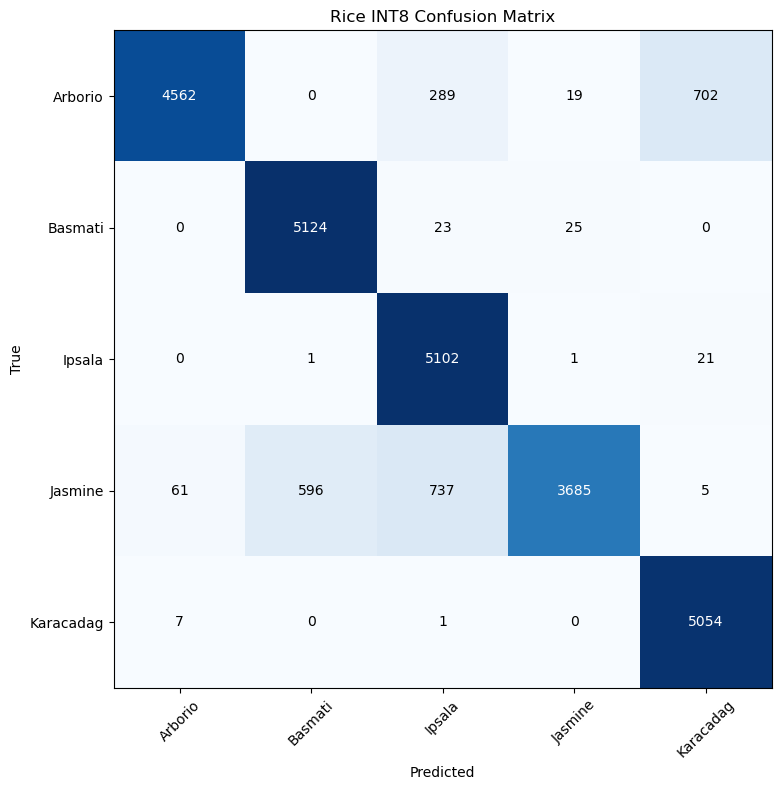

In [52]:
import tensorflow as tf
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

# ==============================
# CONFIG
# ==============================
DATA_DIR = "Rice_Image_Dataset"
IMG_SIZE = 96
TFLITE_PATH = "rice_efficientnet_stm32.tflite"

# ==============================
# 1. Load TFLite INT8 model
# ==============================
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

input_dtype = input_details[0]['dtype']
input_shape = input_details[0]['shape']
scale, zero_point = input_details[0]['quantization']

print("Input dtype:", input_dtype)
print("Input shape:", input_shape)

# ==============================
# 2. Load rice images
# ==============================
X = []
y = []

class_names = sorted(os.listdir(DATA_DIR))

for idx, cls in enumerate(class_names):
    cls_path = os.path.join(DATA_DIR, cls)
    for f in os.listdir(cls_path):
        path = os.path.join(cls_path, f)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img)
        y.append(idx)

X = np.array(X)
y = np.array(y)

print("Classes:", class_names)
print("Total test images:", len(X))

# ==============================
# 3. Run TFLite inference
# ==============================
preds = []

for i in range(len(X)):
    img = X[i]

    # Expand dims for HWC + batch
    img = np.expand_dims(img, axis=-1)  # HWC
    img = np.expand_dims(img, axis=0)   # batch

    # Convert to float 0..1
    img_float = img.astype(np.float32) / 255.0

    # Quantize using scale & zero_point
    img_uint8 = (img_float / scale + zero_point).astype(np.uint8)

    # Set tensor & invoke
    interpreter.set_tensor(input_details[0]['index'], img_uint8)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])

    pred = np.argmax(output)
    preds.append(pred)

preds = np.array(preds)

# ==============================
# 4. Accuracy
# ==============================
acc = np.mean(preds == y) * 100
print(f"\nTFLITE INT8 ACCURACY = {acc:.2f}%")

# ==============================
# 5. Confusion matrix
# ==============================
n = len(class_names)
cm = np.zeros((n,n), dtype=np.int32)

for t,p in zip(y,preds):
    cm[t,p] += 1

print("\nConfusion Matrix")
print(cm)

# ==============================
# 6. Plot confusion matrix
# ==============================
plt.figure(figsize=(8,8))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(n), class_names, rotation=45)
plt.yticks(range(n), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(n):
    for j in range(n):
        plt.text(j, i, cm[i,j], ha="center", va="center",
                 color="white" if cm[i,j] > cm.max()/2 else "black")

plt.title("Rice INT8 Confusion Matrix")
plt.tight_layout()
plt.show()
